<a href="https://colab.research.google.com/github/paulinamena/Integracion-de-datos-y-prospectiva/blob/main/Final_Gesti%C3%B3n_Introspectiva_Seguros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Riesgo operacional en el sector de seguros de hogar
# Casos SURA y MAPFRE Colombia

En este cuaderno se integran dos bases de datos de eventos de riesgo operacional
del ramo de seguro hogar en Colombia: Seguros SURA y MAPFRE, ambas generadas
con apoyo de LLM sobre la estructura y tipología documental de ambas
compañías en el mercado local para el periodo 2022-2026, 1.500 registros cada una.

Cada registro representa un día con siniestros reportados, con variables de:
  *    Frecuencia Diaria de Pérdidas (reclamaciones/día)
  *    Severidad Promedio por Pérdida Diaria (KUSD)
  *    Pérdida Total Diaria (KUSD)
  *    Tipo de Riesgo (10 categorías climáticas y operativas)


## Métodos de integración aplicados:

  · Modelo 1 — **Teoría de Credibilidad + Aceptación y Rechazo**:
    Se mide la afinidad estadística de MAPFRE con SURA por cada Tipo de
    Riesgo usando la Frecuencia Diaria como variable de referencia.
    El factor de credibilidad Z ayuda a guiar el orden de evaluación, y el
    método de Aceptación y Rechazo decide cuáles registros de MAPFRE
    se integran al portafolio de SURA.

  · Modelo 2 — **K-Medoids Multidimensional**:
    Segmenta la base integrada en 5 perfiles de riesgo usando las
    variables de Frecuencia, Severidad y LDA, permitiendo caracterizar
    cada cluster con su perfil operacional propio.

## Gestión prospectiva y captura de gases de efecto invernadero (GEI)

  Sobre el portafolio integrado se aplica la metodología de Riesgo
  Operacional (K-Means 1D · Matrices 5×5 · PE · OpVaR 99.9%) para
  estimar el valor financiero capturado por la gestión activa del riesgo
  y su equivalente en toneladas de CO₂ (usando la tarifa del impuesto al carbono, definida por la DIAN para el 2026 por un valor de 29.070 COP/tCO₂e).

  Este método ayudará a cuantificar el efecto de la gestión de riesgo, con el fin de alcanzar el cumplimiento de metas de medio ambiente, sociedad y gobierno (ESG) para ambas empresas.


### Fuentes

Fuentes de referencia para la calibración estructural:
  * Grupo SURA — Informe de Resultados 2025 (El Colombiano, feb. 2026)
  * MAPFRE Colombia — Resultados 2024 y primas climáticas 2025
  * La República, 2025; MAPFRE Global, feb. 2025
  * Superintendencia Financiera de Colombia — Ramo Hogar, 2024
  * Resolución 000003 de 2026, DIAN



0. Se procede con la carga de las librerias de trabajo

In [ ]:
# Se importan librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:.4f}'.format

# Se monta la carpeta content para almacenar las BD
from google.colab import drive
drive.mount('/content/drive')

# Se ingresa semilla para asegurar la reproductibilidad de los datos
np.random.seed(42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Definimos la función de clusterización de los datos

def clusterizacion(Xi):
    """
    K-Means unidimensional. Clasifica un array numérico en 5 niveles:
      0 → Improbable / Insignificante
      1 → Posible    / Menor
      2 → Ocasional  / Moderado
      3 → Probable   / Mayor
      4 → Frecuente  / Catastrófico
    """
    XC = np.sort(np.random.choice(Xi, size=5))
    nc = np.zeros(len(Xi))
    for k in range(len(Xi)):
        d = np.abs(XC - Xi[k])
        nc[k] = np.argmin(d)
        nc2 = int(nc[k])
        XC[nc2] = (XC[nc2] + Xi[k]) / 2
    return XC, nc.astype(int)


# Definimos la función de caracterización estadística de los datos

def caracterizacion(X, nombre, plot=True):
    media      = round(np.mean(X), 4)
    varianza   = round(np.var(X), 4)
    desviacion = round(np.std(X), 4)
    asimetria  = round(skew(X), 4)
    curtosis_  = round(kurtosis(X), 4)

    print(f"\n  ===== {nombre} =====")
    print(f"  N (registros) : {len(X)}")
    print(f"  Media         : {media}")
    print(f"  Varianza      : {varianza}")
    print(f"  Desviación    : {desviacion}")
    print(f"  Asimetría     : {asimetria}")
    print(f"  Curtosis      : {curtosis_}")

    if plot:
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.histplot(X, bins=20, kde=True, color='steelblue', ax=ax)
        ax.set_title(f"Distribución Frecuencia Diaria — {nombre}", fontweight='bold')
        ax.set_xlabel("Frecuencia Diaria de Pérdidas (reclamaciones/día)")
        ax.set_ylabel("Frecuencia de ocurrencia")
        plt.tight_layout(); plt.show()

    return media, varianza, desviacion, asimetria, curtosis_


1. Se cargan los archivos de trabajo y se extraen las variables de interés.


  DIMENSIONES Y PERÍODO
  SURA: 1500 registros | 2022-01-01 → 2026-02-08
  Tipos de riesgo: ['Anegación de vivienda', 'Daños estructurales', 'Daños por granizo', 'Deslizamientos de tierra', 'Filtraciones y humedad', 'Inundación por lluvias intensas', 'Remoción de escombros', 'Riesgo operativo por aumento de reclamaciones', 'Tormentas eléctricas', 'Vientos fuertes']
  MAPFRE: 1500 registros | 2022-01-01 → 2026-02-08
  Tipos de riesgo: ['Anegación de vivienda', 'Daños estructurales', 'Daños por granizo', 'Deslizamientos de tierra', 'Filtraciones y humedad', 'Inundación por lluvias intensas', 'Remoción de escombros', 'Riesgo operativo por aumento de reclamaciones', 'Tormentas eléctricas', 'Vientos fuertes']

  ===== SURA  (portafolio de referencia) =====
  N (registros) : 1500
  Media         : 9.46
  Varianza      : 13.8511
  Desviación    : 3.7217
  Asimetría     : 0.5942
  Curtosis      : 0.3858


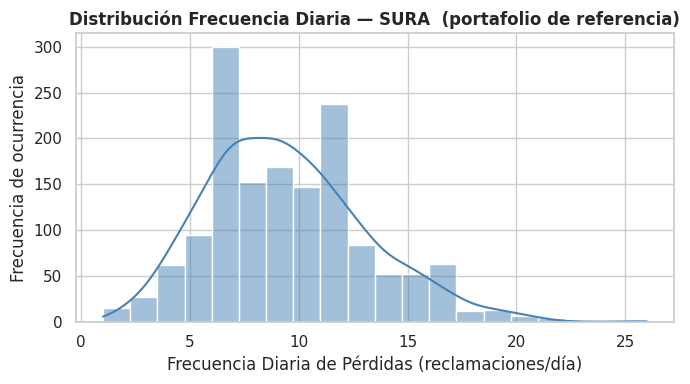


  ===== MAPFRE (portafolio a integrar) =====
  N (registros) : 1500
  Media         : 7.756
  Varianza      : 9.7285
  Desviación    : 3.119
  Asimetría     : 0.508
  Curtosis      : 0.0375


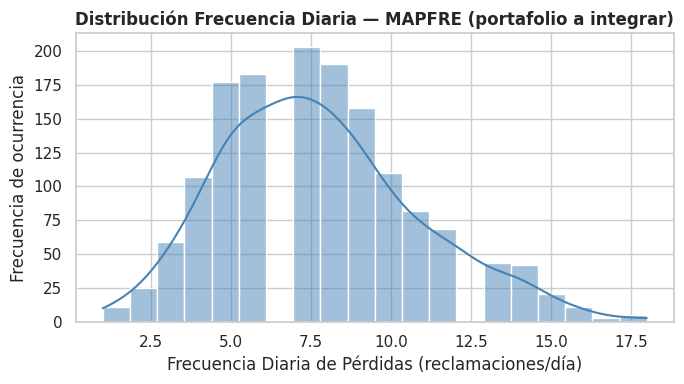

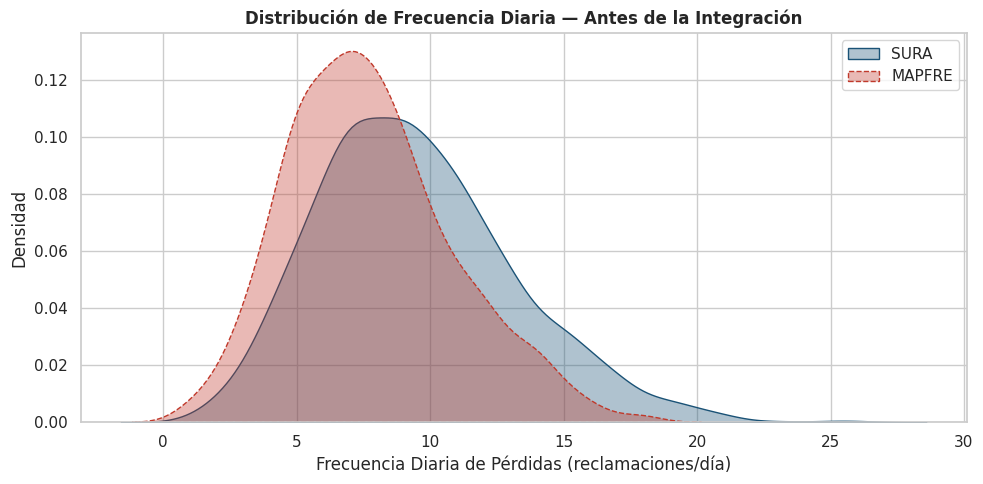

In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  BASE DE DATOS 1 — Seguros SURA Colombia  (portafolio de referencia)        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Fuente    : Generada con LLM sobre estructura documental de SURA            ║
║  Período   : 2022-01-01 → 2026-02-08  |  1.500 registros diarios            ║
║  Empresa   : Seguros Generales Suramericana S.A., Medellín (1944).           ║
║              Tercer mayor grupo asegurador latinoamericano, con el 60.5%    ║
║              de sus primas en Colombia. Redujo siniestros retenidos 1.5%    ║
║              en 2025 (El Colombiano, feb. 2026).                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  VARIABLES                                                                   ║
║  · Frecuencia Diaria de Pérdidas      (int)    : reclamaciones/día          ║
║  · Severidad Promedio por Pérdida     (float)  : KUSD                       ║
║  · Pérdida Total Diaria               (float)  : Freq × Sev en KUSD         ║
║  · Tipo de Riesgo                     (str)    : 10 categorías              ║
║  · Línea de Negocio                   (str)    : Seguro Hogar               ║
╚══════════════════════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════════════════════╗
║  BASE DE DATOS 2 — MAPFRE Colombia  (portafolio a integrar)                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Fuente    : Generada con LLM sobre estructura documental de MAPFRE          ║
║  Período   : 2022-01-01 → 2026-02-08  |  1.500 registros diarios            ║
║  Empresa   : MAPFRE Seguros Generales de Colombia S.A.                       ║
║              Supervisada por la SFC, auditada por KPMG. El ramo Hogar       ║
║              creció 6.8% en 2024 a nivel global (MAPFRE, feb. 2025).        ║
║              Los ramos climáticos en Colombia superaron $800.000M en        ║
║              primas emitidas en 2025 (La República, 2025).                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  VARIABLES: estructura idéntica a SURA  (condición de integración)           ║
╚══════════════════════════════════════════════════════════════════════════════╝

VARIABLE DE REFERENCIA PARA LA INTEGRACIÓN: Frecuencia Diaria de Pérdidas
──────────────────────────────────────────────────────────────────────────
Criterio: La Frecuencia Diaria sigue
una distribución aproximadamente normal con media estable entre las dos
fuentes (SURA ≈ 9.46, MAPFRE ≈ 7.76), facilitando el cálculo de los
parámetros de credibilidad (EPV, VHM, K, Z) y los umbrales de A/R.
Las variables Severidad y LDA complementan el análisis multidimensional.

VARIABLES POTENCIALES DE INTEGRACIÓN (comunes, misma unidad):
  · Frecuencia Diaria  → variable de referencia estadística (Modelo 1)
  · Severidad y LDA    → variables adicionales para clustering (Modelo 2)
  · Tipo de Riesgo     → llave categórica de estratificación
"""

PATH_SURA   = '/content/drive/MyDrive/Integración de Datos/Proyecto_Final/Base_Datos_Riesgo_Seguros_SURA_Colombia.xlsx'
PATH_MAPFRE = '/content/drive/MyDrive/Integración de Datos/Proyecto_Final/Base_Datos_Riesgo_MAPFRE_Colombia.xlsx'

SURA   = pd.read_excel(PATH_SURA)
MAPFRE = pd.read_excel(PATH_MAPFRE)

for nombre, df in [('SURA', SURA), ('MAPFRE', MAPFRE)]:
    df['Fecha'] = pd.to_datetime(df['Fecha'])

VAR_REF = 'Frecuencia Diaria de Pérdidas'

print("\n" + "="*65)
print("  DIMENSIONES Y PERÍODO")
print("="*65)
for nombre, df in [('SURA', SURA), ('MAPFRE', MAPFRE)]:
    print(f"  {nombre}: {len(df)} registros | {df['Fecha'].min().date()} → {df['Fecha'].max().date()}")
    print(f"  Tipos de riesgo: {sorted(df['Tipo de Riesgo'].unique())}")

# ─────────────────────────────────────────────────────────────────────────────
# 1.1.  EDA — CARACTERIZACIÓN ANTES DE LA INTEGRACIÓN
# ─────────────────────────────────────────────────────────────────────────────

sura_freq   = SURA[VAR_REF].values
mapfre_freq = MAPFRE[VAR_REF].values

u_s, var_s, sig_s, ase_s, kur_s = caracterizacion(sura_freq,   "SURA  (portafolio de referencia)")
u_m, var_m, sig_m, ase_m, kur_m = caracterizacion(mapfre_freq, "MAPFRE (portafolio a integrar)")
n_sura   = len(sura_freq)
n_mapfre = len(mapfre_freq)

# ── Visualización comparativa ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.kdeplot(sura_freq,   fill=True, alpha=0.35, color='#1a5276', label='SURA')
sns.kdeplot(mapfre_freq, fill=True, alpha=0.35, color='#c0392b',
            linestyle='--', label='MAPFRE')
plt.title("Distribución de Frecuencia Diaria — Antes de la Integración",
          fontweight='bold')
plt.xlabel("Frecuencia Diaria de Pérdidas (reclamaciones/día)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de los datos antes de integrar:

El análisis exploratorio nos muestra que ambas empresas operan en el mismo ramo con comportamientos distintos, pero compatibles. Mientras que SURA registra en promedio 20% más reclamaciones diarias que MAPFRE, SURA tiene mayor dispersión, y esto se explica por el mayor tamaño de su cartera asegurada en Colombia.

Ahora, ambas distribuciones tienen forma de campana, asimetría positiva, (la mayoría de días concentran de 5 a 12 reclamaciones) con días excepcionales que superan las 20.




2. Se aplica el método #1 de integración (credibilidad + aceptación y rechazo)


  MODELO 1 — TEORÍA DE CREDIBILIDAD POR TIPO DE RIESGO

  --- SURA vs MAPFRE · Anegación de vivienda ---
  EPV=12.8104  VHM=0.5542  K=23.1137  Z=0.8633  (86.3%)

  --- SURA vs MAPFRE · Daños estructurales ---
  EPV=11.9322  VHM=0.6230  K=19.1518  Z=0.8840  (88.4%)

  --- SURA vs MAPFRE · Daños por granizo ---
  EPV=13.0020  VHM=0.8811  K=14.7563  Z=0.9065  (90.6%)

  --- SURA vs MAPFRE · Deslizamientos de tierra ---
  EPV=12.2727  VHM=1.0391  K=11.8112  Z=0.9339  (93.4%)

  --- SURA vs MAPFRE · Filtraciones y humedad ---
  EPV=10.9982  VHM=0.9009  K=12.2074  Z=0.9344  (93.4%)

  --- SURA vs MAPFRE · Inundación por lluvias intensas ---
  EPV=11.4902  VHM=0.8008  K=14.3484  Z=0.9116  (91.2%)

  --- SURA vs MAPFRE · Remoción de escombros ---
  EPV=11.4124  VHM=0.6727  K=16.9656  Z=0.8869  (88.7%)

  --- SURA vs MAPFRE · Riesgo operativo por aumento de reclamaciones ---
  EPV=12.2493  VHM=1.0358  K=11.8265  Z=0.9231  (92.3%)

  --- SURA vs MAPFRE · Tormentas eléctricas ---
  EPV=11.2820  

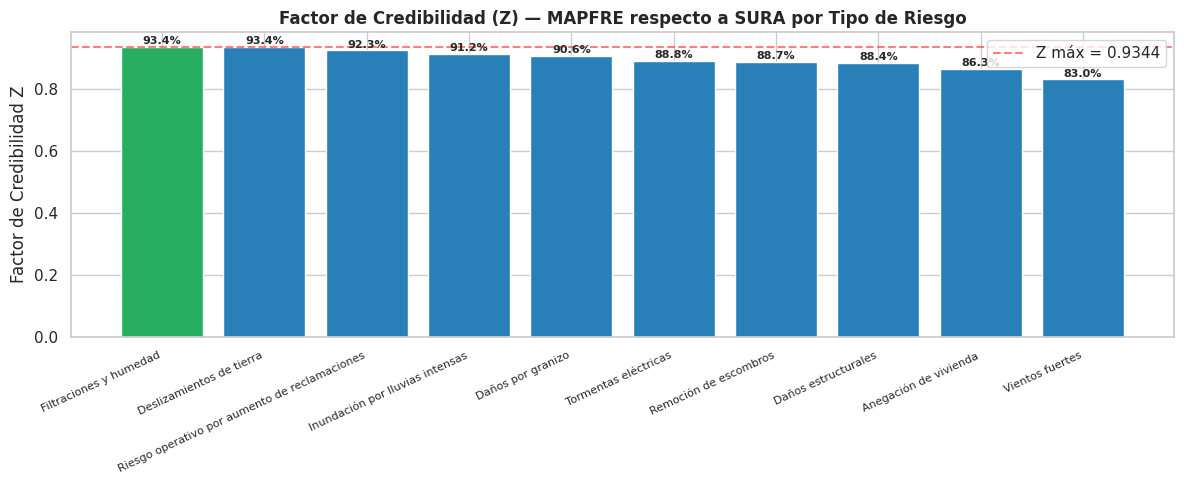


  ACEPTACIÓN Y RECHAZO — Integración de registros MAPFRE → SURA
  Umbral VP: 0.7  |  Orden de evaluación (Z desc): 
    1. Filtraciones y humedad  (Z=93.4%)
    2. Deslizamientos de tierra  (Z=93.4%)
    3. Riesgo operativo por aumento de reclamaciones  (Z=92.3%)
    4. Inundación por lluvias intensas  (Z=91.2%)
    5. Daños por granizo  (Z=90.6%)
    6. Tormentas eléctricas  (Z=88.8%)
    7. Remoción de escombros  (Z=88.7%)
    8. Daños estructurales  (Z=88.4%)
    9. Anegación de vivienda  (Z=86.3%)
    10. Vientos fuertes  (Z=83.0%)

  ===== RESULTADO ACEPTACIÓN Y RECHAZO =====
  Filtraciones y humedad                              706 registros aceptados (47.1%)
  Deslizamientos de tierra                             88 registros aceptados (5.9%)
  Riesgo operativo por aumento de reclamaciones        46 registros aceptados (3.1%)
  Inundación por lluvias intensas                       3 registros aceptados (0.2%)
  Daños por granizo                                     1 registros ac

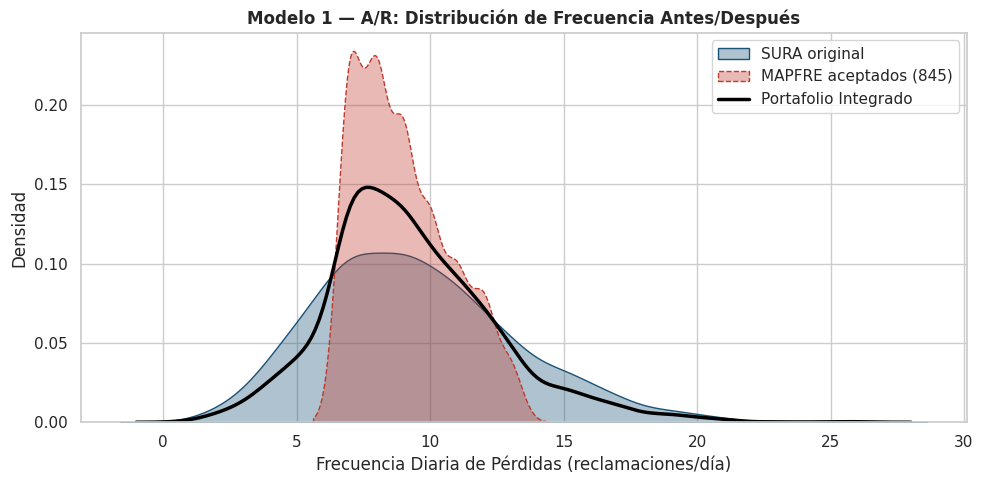


  ===== COMPARACIÓN DE MÉTODOS =====
  Tipo de Riesgo                                         Val. Pertenencia   Acep./Rechazo
  ───────────────────────────────────────────────────────────────────────────────────────
  Anegación de vivienda                                                 0               0
  Daños estructurales                                                   0               0
  Daños por granizo                                                     0               1
  Deslizamientos de tierra                                              0              88
  Filtraciones y humedad                                                0             706
  Inundación por lluvias intensas                                       0               3
  Remoción de escombros                                                 0               0
  Riesgo operativo por aumento de reclamaciones                       305              46
  Tormentas eléctricas                                        

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
# MODELO DE INTEGRACIÓN 1
# TEORÍA DE CREDIBILIDAD + ACEPTACIÓN Y RECHAZO
# ══════════════════════════════════════════════════════════════════════════════
#
# PERTINENCIA DEL MODELO
# ──────────────────────
# La Teoría de Credibilidad es pertinente cuando se desea ponderar el grado
# de confianza que merece la información de una fuente respecto a otra con
# distribuciones estadísticas similares pero no idénticas.
#
# En este caso, SURA constituye el portafolio de referencia y MAPFRE es el
# portafolio a integrar.  La Frecuencia Diaria actúa
# como variable de referencia.
#
# El factor Z se calcula POR TIPO DE RIESGO, revelando en cuáles categorías
# MAPFRE es estadísticamente más o menos afín a SURA.  Los tipos con Z más
# alto son los que el modelo prioriza en la integración.
#
# La Aceptación y Rechazo luego procesa CADA REGISTRO de MAPFRE: si su
# Frecuencia Diaria es compatible con la distribución de SURA para ese
# mismo Tipo de Riesgo (VP > UMBRAL y VP > U ~ Unif(0,1)), el registro
# se acepta en el portafolio integrado.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65)
print("  MODELO 1 — TEORÍA DE CREDIBILIDAD POR TIPO DE RIESGO")
print("="*65)

tipos_riesgo = sorted(SURA['Tipo de Riesgo'].unique())

# ── 2.1 Caracterización por Tipo de Riesgo ───────────────────────────────
stats_sura   = {}
stats_mapfre = {}

for tipo in tipos_riesgo:
    xs = SURA[SURA['Tipo de Riesgo'] == tipo][VAR_REF].values
    xm = MAPFRE[MAPFRE['Tipo de Riesgo'] == tipo][VAR_REF].values
    stats_sura[tipo]   = {'X': xs, 'n': len(xs), 'u': np.mean(xs), 'sig': np.std(xs)}
    stats_mapfre[tipo] = {'X': xm, 'n': len(xm), 'u': np.mean(xm), 'sig': np.std(xm)}

# ── 2.2 Factor de Credibilidad Z por Tipo de Riesgo ──────────────────────
credibilidades = {}
resultados_cred = []

for tipo in tipos_riesgo:
    s  = stats_sura[tipo]
    m  = stats_mapfre[tipo]

    # Media hipotética combinada
    uhat = (s['n'] * s['u'] + m['n'] * m['u']) / (s['n'] + m['n'])

    # Varianza esperada del proceso (EPV) — promedio ponderado de varianzas
    EPV  = (s['n'] * s['sig']**2 + m['n'] * m['sig']**2) / (s['n'] + m['n'])

    # Varianza de la media hipotética (VHM) — variabilidad entre fuentes
    VHM  = ((s['n'] * s['u']**2 + m['n'] * m['u']**2) / (s['n'] + m['n'])) - uhat**2
    VHM  = max(VHM, 1e-6)

    K = EPV / VHM
    Z = m['n'] / (m['n'] + K)   # Credibilidad de MAPFRE respecto a SURA

    credibilidades[tipo] = {'K': K, 'Z': Z, 'uhat': uhat}
    resultados_cred.append({'Tipo de Riesgo': tipo,
                            'Z': round(Z, 4), 'Z%': f"{Z*100:.1f}%",
                            'K': round(K, 4),
                            'Media SURA': round(s['u'], 2),
                            'Media MAPFRE': round(m['u'], 2)})

    print(f"\n  --- SURA vs MAPFRE · {tipo} ---")
    print(f"  EPV={EPV:.4f}  VHM={VHM:.4f}  K={K:.4f}  Z={Z:.4f}  ({Z*100:.1f}%)")

df_cred = pd.DataFrame(resultados_cred).sort_values('Z', ascending=False)
print("\n  ===== RESUMEN DE CREDIBILIDADES =====")
print(df_cred.to_string(index=False))

tipo_mayor_z = df_cred.iloc[0]['Tipo de Riesgo']
Z_mayor      = df_cred.iloc[0]['Z']
print(f"\n  ► Tipo de riesgo con mayor afinidad estadística: '{tipo_mayor_z}' (Z={Z_mayor*100:.1f}%)")
print(f"  ► Todos los tipos superan Z=80%, confirmando alta compatibilidad de mercado.")

# ── Visualización del factor Z ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
tipos_ord  = df_cred['Tipo de Riesgo'].tolist()
zs_ord     = df_cred['Z'].tolist()
colores_z  = ['#27ae60' if t == tipo_mayor_z else '#2980b9' for t in tipos_ord]
bars       = ax.bar(range(len(tipos_ord)), zs_ord, color=colores_z, edgecolor='white')
ax.set_xticks(range(len(tipos_ord)))
ax.set_xticklabels(tipos_ord, rotation=25, ha='right', fontsize=8)
ax.axhline(max(zs_ord), linestyle='--', color='red', alpha=0.5,
           label=f'Z máx = {max(zs_ord):.4f}')
ax.set_ylabel("Factor de Credibilidad Z")
ax.set_title("Factor de Credibilidad (Z) — MAPFRE respecto a SURA por Tipo de Riesgo",
             fontweight='bold')
for bar, z in zip(bars, zs_ord):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{z*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2.3  MÉTODO DE ACEPTACIÓN Y RECHAZO
# ─────────────────────────────────────────────────────────────────────────────
"""
Para cada registro de MAPFRE se evalúan los Tipos de Riesgo en orden
DESCENDENTE de credibilidad Z.  Por cada tipo candidato se calcula el
Valor de Pertenencia del registro respecto a la distribución de SURA:

    VP = exp(-0.5 * ((μ_SURA_tipo - Freq_registro) / σ_SURA_tipo)²)

El registro es ACEPTADO si: VP > UMBRAL  AND  VP > U ~ Unif(0,1)
Si ningún tipo lo acepta, el registro queda sin asignar.
"""

UMBRAL = 0.70   # Umbral de compatibilidad estadística

# Orden de evaluación: tipos de riesgo de mayor a menor Z
orden_tipos = df_cred['Tipo de Riesgo'].tolist()

# Base integrada (copia de SURA como punto de partida)
BASE_INTEGRADA = SURA.copy()
conteo_ar  = {tipo: 0 for tipo in tipos_riesgo}
no_asig_ar = 0
registros_aceptados = []

print("\n" + "="*65)
print("  ACEPTACIÓN Y RECHAZO — Integración de registros MAPFRE → SURA")
print("="*65)
print(f"  Umbral VP: {UMBRAL}  |  Orden de evaluación (Z desc): ")
for i, t in enumerate(orden_tipos, 1):
    print(f"    {i}. {t}  (Z={credibilidades[t]['Z']*100:.1f}%)")

for idx, fila in MAPFRE.iterrows():
    freq_paciente = fila[VAR_REF]
    tipo_orig     = fila['Tipo de Riesgo']
    asignado      = None

    for tipo_eval in orden_tipos:
        s  = stats_sura[tipo_eval]
        VP = np.exp(-0.5 * ((s['u'] - freq_paciente) / s['sig']) ** 2)
        U  = np.random.uniform(0, 1)

        if VP > UMBRAL and VP > U:
            asignado = tipo_eval
            conteo_ar[tipo_eval] += 1
            registro_nuevo = fila.copy()
            registro_nuevo['Tipo de Riesgo']  = tipo_eval   # reasignado al tipo afín
            registro_nuevo['Fuente_Original'] = 'MAPFRE'
            registros_aceptados.append(registro_nuevo)
            break

    if asignado is None:
        no_asig_ar += 1

MAPFRE_ACEPTADOS = pd.DataFrame(registros_aceptados)
SURA['Fuente_Original'] = 'SURA'
BASE_INTEGRADA = pd.concat([SURA, MAPFRE_ACEPTADOS], ignore_index=True)

total_integrados = sum(conteo_ar.values())
print(f"\n  ===== RESULTADO ACEPTACIÓN Y RECHAZO =====")
for tipo, n in sorted(conteo_ar.items(), key=lambda x: -x[1]):
    pct = n / len(MAPFRE) * 100
    print(f"  {tipo:<50} {n:>4} registros aceptados ({pct:.1f}%)")
print(f"\n  Sin asignar (VP < {UMBRAL} en todos los tipos): {no_asig_ar}")
print(f"  Total MAPFRE integrados:  {total_integrados} / {len(MAPFRE)}  ({total_integrados/len(MAPFRE)*100:.1f}%)")
print(f"  Base Integrada total:     {len(BASE_INTEGRADA)} registros (SURA original + MAPFRE aceptados)")

# ─────────────────────────────────────────────────────────────────────────────
# 2.4  VALIDACIÓN ESTADÍSTICA — ANTES vs DESPUÉS
# ─────────────────────────────────────────────────────────────────────────────

print("\n  ===== VALIDACIÓN ESTADÍSTICA — ANTES vs DESPUÉS (A/R) =====")
print(f"  {'Métrica':<12} {'SURA orig':>12} {'Integrada':>12} {'Discrepancia':>14}")
print(f"  {'─'*52}")

for metrica, antes, despues in [
    ('Media',      np.mean(sura_freq),                    np.mean(BASE_INTEGRADA[VAR_REF])),
    ('Sigma',      np.std(sura_freq),                     np.std(BASE_INTEGRADA[VAR_REF])),
    ('Asimetría',  skew(sura_freq),                       skew(BASE_INTEGRADA[VAR_REF])),
    ('Curtosis',   kurtosis(sura_freq),                   kurtosis(BASE_INTEGRADA[VAR_REF]))]:

    disc = abs((antes - despues) / antes) * 100 if antes != 0 else 0
    print(f"  {metrica:<12} {round(antes,4):>12} {round(despues,4):>12} {round(disc,2):>13}%")

print(f"\n  ► Una discrepancia < 5% en todas las métricas confirma que los registros")
print(f"    aceptados son estadísticamente compatibles con el portafolio de referencia.")

# ── Comparación de distribuciones antes/después ────────────────────────────
plt.figure(figsize=(10, 5))
sns.kdeplot(sura_freq,                    fill=True, alpha=0.35,
            color='#1a5276', label='SURA original')
sns.kdeplot(MAPFRE_ACEPTADOS[VAR_REF],   fill=True, alpha=0.35,
            color='#c0392b', linestyle='--', label=f'MAPFRE aceptados ({total_integrados})')
sns.kdeplot(BASE_INTEGRADA[VAR_REF],     fill=False, linewidth=2.5,
            color='black', linestyle='-', label='Portafolio Integrado')
plt.title("Modelo 1 — A/R: Distribución de Frecuencia Antes/Después",
          fontweight='bold')
plt.xlabel("Frecuencia Diaria de Pérdidas (reclamaciones/día)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

# ── Comparación de métodos VP vs A/R ─────────────────────────────────────
# (Valor de Pertenencia puro, sin componente estocástica)
conteo_vp  = {tipo: 0 for tipo in tipos_riesgo}
no_asig_vp = 0
for _, fila in MAPFRE.iterrows():
    freq_p = fila[VAR_REF]
    vps = {t: np.exp(-0.5 * ((stats_sura[t]['u'] - freq_p) / stats_sura[t]['sig'])**2)
           for t in tipos_riesgo}
    candidatos = {t: v for t, v in vps.items() if v > UMBRAL}
    if candidatos:
        mejor = max(candidatos, key=candidatos.get)
        conteo_vp[mejor] += 1
    else:
        no_asig_vp += 1

print("\n  ===== COMPARACIÓN DE MÉTODOS =====")
print(f"  {'Tipo de Riesgo':<52} {'Val. Pertenencia':>18} {'Acep./Rechazo':>15}")
print(f"  {'─'*87}")
for tipo in sorted(tipos_riesgo):
    print(f"  {tipo:<52} {conteo_vp[tipo]:>18} {conteo_ar[tipo]:>15}")
print(f"  {'Sin asignar':<52} {no_asig_vp:>18} {no_asig_ar:>15}")

## Conclusión del método #1

### 2.1 Credibilidad

El factor Z ayuda a explicar ¿qué tanto le podemos creer a la experiencia de MAPFRE para explicar lo que le pasa a SURA? Recordemos que un Z cercano a 1 indica alta afinidad; cercano a 0 indica baja. En este caso, todos los riesgos superaron el 83%, sugiriendo que así sea un evento de inundación, deslizamiento, o cualquier tipo de siniestro, ambas empresas observan el mercado de forma coherente.

La media del portafolio integrado presenta una discrepancia de apenas
1.68% respecto a SURA original, lo que confirma que la tendencia central se preservó. Las discrepancias en sigma (15.0%), asimetría (27.83%) y curtosis (251.69%) reflejan que los registros aceptados de MAPFRE son más homogéneos y menos extremos que los de SURA, lo cual es estadísticamente esperado dado el umbral VP > 0.70 aplicado.

Los tipos con mayor afinidad fueron **Filtraciones y humedades** y **deslizamientos de tierra** con un **Z=93.4%**. Estos son fenómenos muy frecuentes en temporadas de lluvias, y sugieren que el alcance geográfico de las zonas de riesgo por clima para ambas empresas es el mismo.

**Vientos fuertes** presenta un bajo Z, indicando diferencias en la cobertura de inmuebles en zonas de mayor dificultad geográfica, por ejemplo.

Por su parte, el parámetro K, que mide qué tanto varía internamente cada empresa frente a la variabilidad de ambas, refleja que el modelo es más conservador antes de integrar datos.

### 2.2. Aceptación y rechazo

De los registros de MAPFRE, el modelo acepta el 56.3% de los datos, rechazando 655 restantes por no superar el umbral de compatibilidad (VP > 0.70), recordemos que esta, más que una falla, es una garantía de integridad: solo aquellos registros con frecuencia diaria es coherente con el comportamiento de SURA entran al modelo.

La zona de aceptación estuvo compuesta principalmente por **Filtraciones y humedad**, esto ocurre por la mayor afinidad estadísitica y por ser la tendencia en MAPFRE.  El método de Aceptación y Rechazo evalúa en orden descendente de Z, de modo que el primer tipo que "captura" un registro lo retiene — y Filtraciones y humedad, al ser el primero de la lista, absorbe la mayor proporción.

### 2.3. Sobre la validación estadística

Después de integrar, la media del portafolio combinado quedó en 9.30 reclamaciones por día, apenas 1.68% por debajo de la media original de SURA (9.46). Eso es excelente: la tendencia central se conservó prácticamente intacta.

Sin embargo, hubo cambios en la distribución (aumento en la simetría y en la curtosis), resultando más simétrica que la original y esto ocurrió porque el umbral de 70% provocó filtros extremos de MAPFRE.

3. Se aplica el método #2 de integración (k-Medoids multidimensional con perfiles de riesgo)


  MODELO 2 — K-MEDOIDS MULTIDIMENSIONAL con (k=5 perfiles de riesgo)

  Registros válidos para K-Medoids: 2345
  ✔ K-Medoids finalizado (5 iteraciones)

  ===== PERFILES DE RIESGO POR CLUSTER =====

  Perfil 1 — 838 eventos (35.7%)
    Frecuencia media:  8.01 rec/día
    Severidad media:   37.2775 KUSD
    LDA media:         298.0683 KUSD

  Perfil 2 — 316 eventos (13.5%)
    Frecuencia media:  10.74 rec/día
    Severidad media:   122.6680 KUSD
    LDA media:         1292.1404 KUSD

  Perfil 3 — 413 eventos (17.6%)
    Frecuencia media:  8.13 rec/día
    Severidad media:   88.5970 KUSD
    LDA media:         705.7884 KUSD

  Perfil 4 — 208 eventos (8.9%)
    Frecuencia media:  5.13 rec/día
    Severidad media:   60.5113 KUSD
    LDA media:         311.8998 KUSD

  Perfil 5 — 570 eventos (24.3%)
    Frecuencia media:  12.77 rec/día
    Severidad media:   46.7365 KUSD
    LDA media:         591.9262 KUSD


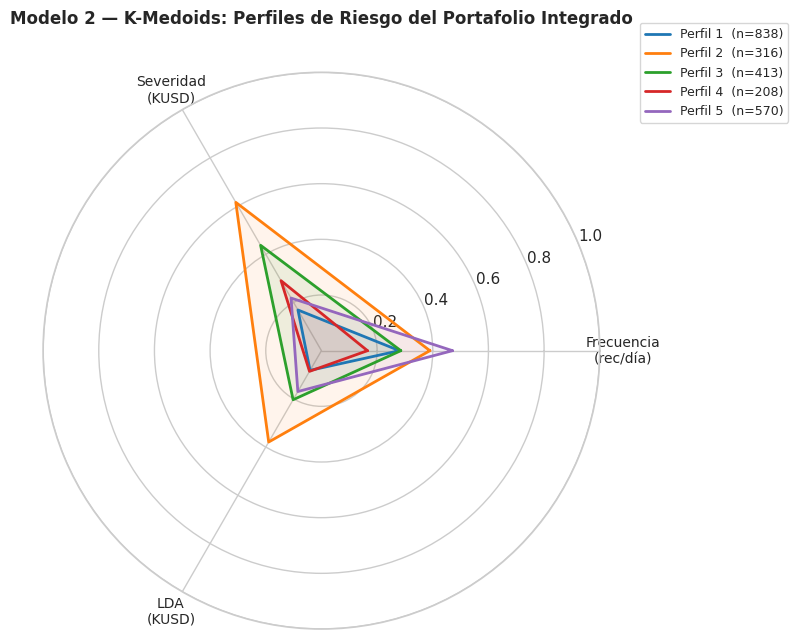

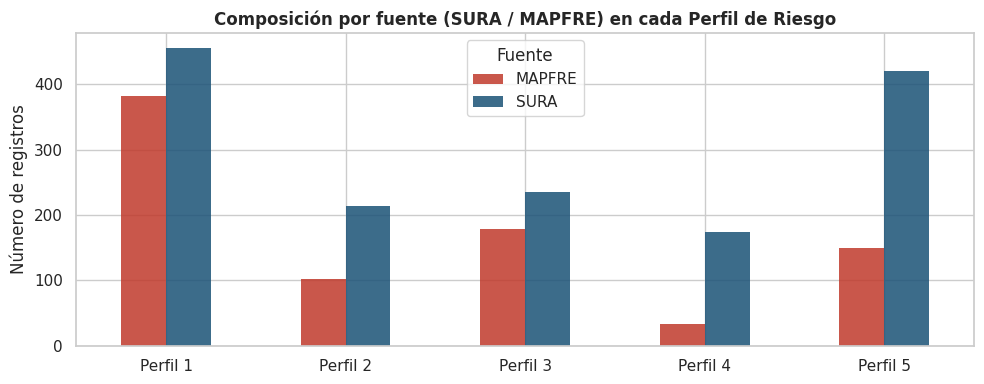

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
# MODELO DE INTEGRACIÓN 2
# K-MEDOIDS MULTIDIMENSIONAL — Perfiles de Riesgo
# ══════════════════════════════════════════════════════════════════════════════
#
# PERTINENCIA DEL MODELO
# ──────────────────────
# El K-Medoids es pertinente cuando se desea segmentar un portafolio
# combinado en grupos homogéneos USANDO MÚLTIPLES VARIABLES SIMULTÁNEAS.
# A diferencia del Modelo 1 (que opera variable por variable),
# el K-Medoids captura relaciones multidimensionales entre Frecuencia,
# Severidad y LDA, generando k=5 perfiles de riesgo que agrupan eventos
# con comportamiento integral similar, independientemente de su fuente.
#
# Los 5 clusters resultantes pueden interpretarse como:
#   · Cluster 1-2: eventos de baja exposición (frecuentes pero leves)
#   · Cluster 3:   eventos de riesgo moderado
#   · Cluster 4-5: eventos de alta exposición (catastróficos)
#
# Esto transforma el portafolio integrado en una estructura segmentada
# que alimenta directamente la metodología de riesgo operacional.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65)
print("  MODELO 2 — K-MEDOIDS MULTIDIMENSIONAL con (k=5 perfiles de riesgo)")
print("="*65)

vars_km = ['Frecuencia Diaria de Pérdidas',
           'Severidad Promedio por Pérdida Diaria (KUSD)',
           'Pérdida Total Diaria (KUSD)']

# Preparación — solo filas sin nulos
XN = BASE_INTEGRADA[vars_km].dropna().copy()
print(f"\n  Registros válidos para K-Medoids: {len(XN)}")

# Normalización Min-Max
XN_norm = (XN - XN.min()) / (XN.max() - XN.min())
XD      = XN_norm.values
k       = 5

# ── K-Medoids optimizado ─────────────────────────────────────────────────
medoid_idx = list(range(k))
max_iter   = 5

for it in range(max_iter):
    dist_matrix = np.array([
        [np.linalg.norm(x - XD[m]) for m in medoid_idx]
        for x in XD
    ])
    labels = np.argmin(dist_matrix, axis=1)
    cambio = False

    for m in range(k):
        cluster_pts = np.where(labels == m)[0]
        if len(cluster_pts) == 0:
            continue
        sub_X      = XD[cluster_pts]
        dist_cl    = np.array([[np.linalg.norm(p1 - p2) for p2 in sub_X] for p1 in sub_X])
        suma_dist  = dist_cl.sum(axis=1)
        mejor      = cluster_pts[np.argmin(suma_dist)]
        if mejor != medoid_idx[m]:
            medoid_idx[m] = mejor
            cambio = True

    if not cambio:
        break

print(f"  ✔ K-Medoids finalizado ({it+1} iteraciones)")

nc_km = labels
BASE_INT_KM = BASE_INTEGRADA[vars_km].dropna().copy().reset_index(drop=True)
BASE_INT_KM['Cluster'] = nc_km

# Calcular perfil de cada cluster en escala original
print("\n  ===== PERFILES DE RIESGO POR CLUSTER =====")
for j in range(k):
    sub  = BASE_INT_KM[BASE_INT_KM['Cluster'] == j]
    n    = len(sub)
    f_m  = sub[vars_km[0]].mean()
    s_m  = sub[vars_km[1]].mean()
    l_m  = sub[vars_km[2]].mean()
    print(f"\n  Perfil {j+1} — {n} eventos ({n/len(BASE_INT_KM)*100:.1f}%)")
    print(f"    Frecuencia media:  {f_m:.2f} rec/día")
    print(f"    Severidad media:   {s_m:.4f} KUSD")
    print(f"    LDA media:         {l_m:.4f} KUSD")

# ── Gráfico de araña (radar) ──────────────────────────────────────────────
N       = len(vars_km)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]
etiq_radar = ['Frecuencia\n(rec/día)', 'Severidad\n(KUSD)', 'LDA\n(KUSD)']
colores_km = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for j in range(k):
    sub     = BASE_INT_KM[BASE_INT_KM['Cluster'] == j]
    vals    = sub[vars_km].mean()
    vals_n  = (vals - XN.min()) / (XN.max() - XN.min())
    vals_l  = vals_n.tolist() + [vals_n.tolist()[0]]
    ax.plot(angulos, vals_l, linewidth=2, color=colores_km[j],
            label=f"Perfil {j+1}  (n={len(sub)})")
    ax.fill(angulos, vals_l, alpha=0.08, color=colores_km[j])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiq_radar, size=10)
ax.set_ylim(0, 1)
ax.set_title("Modelo 2 — K-Medoids: Perfiles de Riesgo del Portafolio Integrado\n",
             size=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

# ── Distribución de fuentes por cluster ───────────────────────────────────
fuentes_km = BASE_INTEGRADA[vars_km + ['Fuente_Original']].dropna().reset_index(drop=True)
fuentes_km['Cluster'] = nc_km

fig, ax = plt.subplots(figsize=(10, 4))
cluster_fuente = (fuentes_km.groupby(['Cluster', 'Fuente_Original'])
                  .size().unstack(fill_value=0))
cluster_fuente.plot(kind='bar', ax=ax,
                    color=['#c0392b', '#1a5276'], edgecolor='none', alpha=0.85)
ax.set_xticklabels([f'Perfil {j+1}' for j in range(k)], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("Número de registros")
ax.set_title("Composición por fuente (SURA / MAPFRE) en cada Perfil de Riesgo",
             fontweight='bold')
ax.legend(title="Fuente")
plt.tight_layout()
plt.show()

## Conclusión del método #2:

El K-Medoids toma los 2345 registros del integrado y los agrupa en 5 perfiles usando frecuencia, severidad y pérdida total diaria, todas al mismo tiempo.

Se obtuvo la siguiente perfilación

*   Perfil 1: Un día típico (838 eventos, 35.7%) Son los días de operación normal que se gestionan con protocolos rutinarios y no presionan las reservas de la compañía.

*   Perfil 2: Día crítico (316 eventos, 13.5%)
Once reclamaciones por día pero con pérdidas individuales mucho más altas debido a algún evento una granizada intensa, una inundación, un deslizamiento. Son los que determinan cuánto capital de emergencia deben tener las aseguradoras.

*   Perfil 3: Día de alertamiento  (413 eventos, 17.6%) Se generan pérdidas por encima de la media pero que no son catastróficos, se requiere atención activa (planes de emergencia, refuerzo de personal)

*   Perfil 4: El día tranquilo (208 eventos, 8.9%) Apenas cinco reclamaciones por día y pérdidas moderadas. Son los días de menor actividad siniestral


*   Perfil 4: El día de avalancha (570 eventos, 24.3%) Tiene la mayor cantidad de reclamaciones por día, pero cada una es más pequeña que en los otros perfiles. Son los días de eventos climáticos masivos pero de impacto individual moderado, como lluvias y humedades.

El gráfico de araña muestra como el perfil 2 se expande hacia la veracidad, el perfil 5 se expande hacia la frecuencia, y el perfil 5 se muestra como el más comprimido al centro (muchos eventos pero moderados)


4. Se procede con la gestión prospectiva de los datos para el cálculo del valor financiero capturado


  PROSPECTIVA — RIESGO OPERACIONAL Y CAPTURA DE GEI

  Portafolio integrado: 2345 registros
  Frecuencia: [1, 26], media=9.30
  Severidad:  [5.00, 196.21], media=62.1827 KUSD
  LDA:        [25.00, 3368.50], media=576.4867 KUSD

Ingresar el Nivel de Gestión — NG (1, 2, 3 ó 4): 2
  NG = 2 | Costo: 0.00025 KUSD  |  Descripción: Planes de contingencia y reservas

Resumen del portafolio clusterizado:
           Freq   Nivel_F       Sev   Nivel_S       LDA
count 2345.0000 2345.0000 2345.0000 2345.0000 2345.0000
mean     9.3015    1.7484   62.1827    1.5697  576.4867
std      3.1643    1.1126   33.4321    1.2232  381.6170
min      1.0000    0.0000    5.0000    0.0000   25.0000
25%      7.0000    1.0000   37.7600    1.0000  314.9300
50%      9.0000    1.0000   51.8300    1.0000  475.3000
75%     11.0000    3.0000   82.5500    2.0000  740.0400
max     26.0000    4.0000  196.2100    4.0000 3368.5000


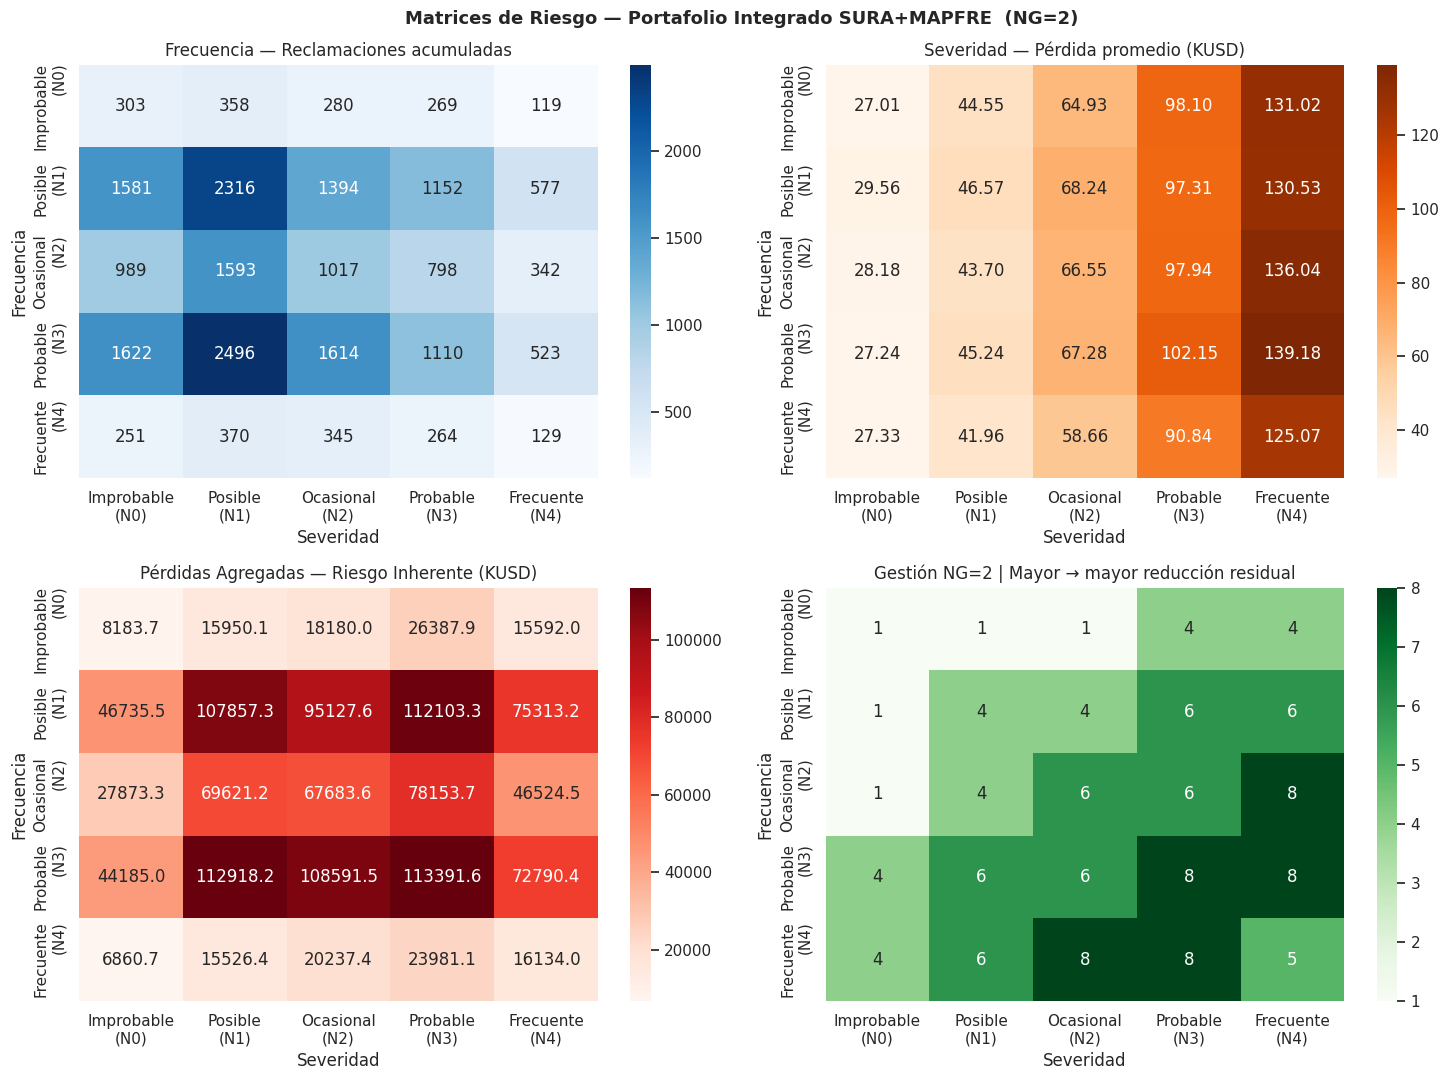


  PÉRDIDA ESPERADA — Portafolio Integrado SURA + MAPFRE
  PE simple (sin ponderar):               73.4077  KUSD
  PE ponderada por frecuencia:            61.7047  KUSD
  PE Riesgo Inherente (con MI):           69.7949  KUSD
  PE Riesgo Residual  (NG=2):            36.3024  KUSD
  Reducción por gestión:                  33.4924  KUSD  (48.0%)

  COMPARATIVO ESCENARIOS  A (Inherente) vs B (Residual)
  Métrica                              Inherente   Residual  Reducción
  ─────────────────────────────────────────────────────────────────
  Pérdida Esperada (PE)                 576.4867   316.7215   259.7652
  OpVaR 99.9%                          2709.9389  2463.4125   246.5264
  Pérdida Máxima                       3368.5000  3368.5000     0.0000

  Capital regulatorio liberado: 246.5264 KUSD
  Eficiencia del control:       9.1%


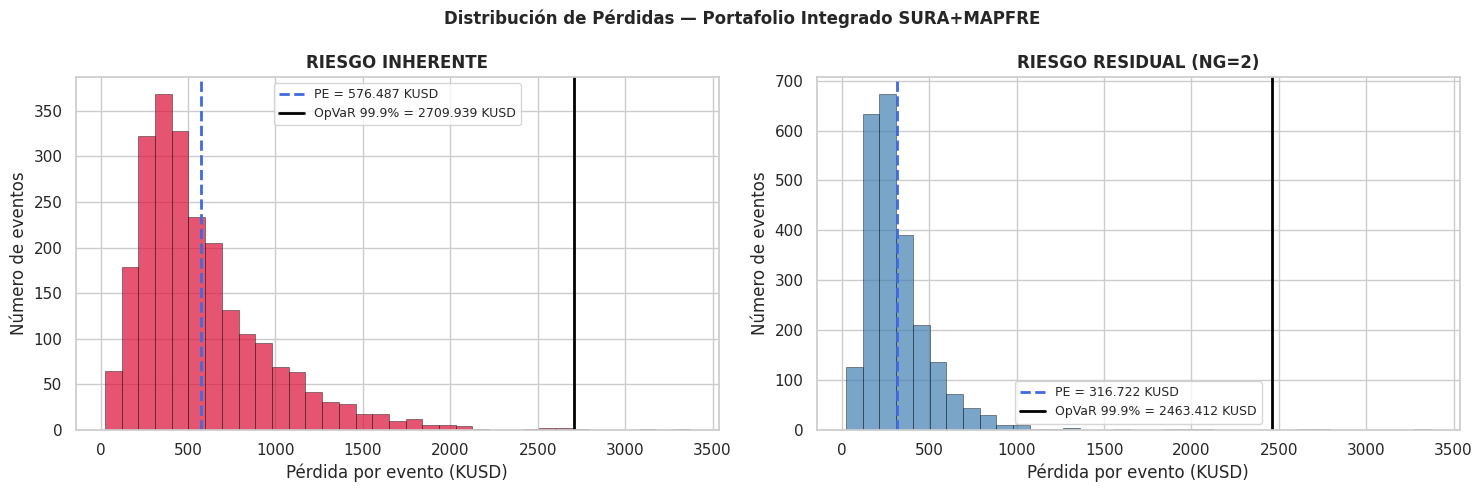


  VALOR FINANCIERO CAPTURADO Y POTENCIAL GEI  (NG=2)
  C1 (esperadas,      LDA < 576.49):       12191 reclamaciones
  C2 (no esperadas,   LDA ∈ C1-OpVaR):     9564 reclamaciones
  C3 (catastróficas,  LDA ≥ 2709.94): 57 reclamaciones

  Reclamaciones que migran C2 → C1:   7234
  Severidad promedio por reclamación:      62.18266 KUSD  ← unidad coherente
  [Referencia] LDA promedio por día:       576.48670 KUSD  (no se usa en VCapt)
  Costo de gestión NG=2:              0.00025 KUSD
  Valor Capturado Financiero:          449825.7217 KUSD
  Precio referencia GEI (DIAN 2024):   0.00767 KUSD/tCO₂e  (USD 7.67)

  ► POTENCIAL DE CAPTURA GEI:  58,647,421.34  tCO₂e / año

  INTERPRETACIÓN:
  El valor capturado no representa emisiones físicas evitadas, sino
  el equivalente financiero en el mercado de carbono colombiano del
  beneficio económico generado por la gestión activa del riesgo.
  Si este capital liberado se reinvirtiera en proyectos de mitigación
  (reforestación, eficiencia energética

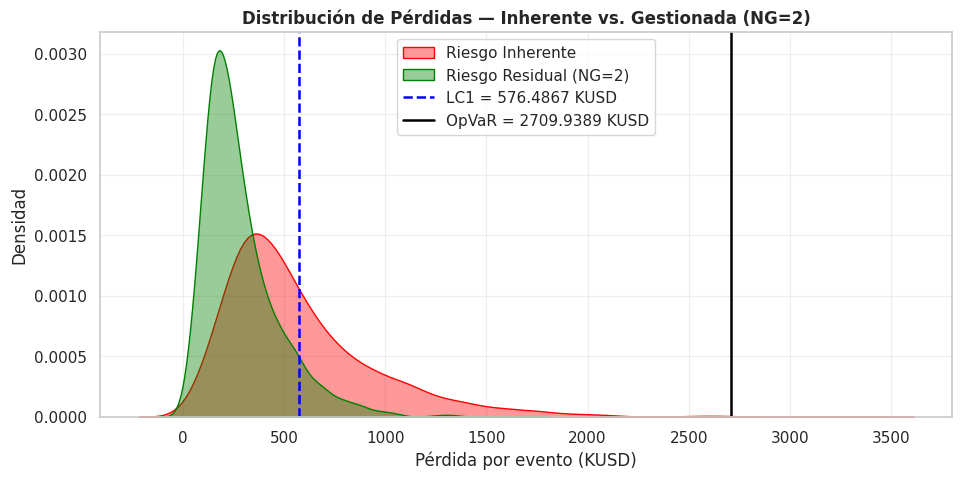

Dropdown(description='Frecuencia:', index=2, layout=Layout(width='440px'), options=(('N0 — Improbable', 0), ('…

Dropdown(description='Severidad:', index=2, layout=Layout(width='440px'), options=(('N0 — Improbable', 0), ('N…

Output()

✅ HTML generado: index.html


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
# PROSPECTIVA — GESTIÓN DE RIESGO Y CAPTURA DE GEI
# ══════════════════════════════════════════════════════════════════════════════
#
# BASE DE DATOS PARA LA PROSPECTIVA
# ──────────────────────────────────
# La base integrada (SURA + MAPFRE aceptados) constituye la "base de datos de
# eventos de riesgo" requerida por el reto. Cada registro documenta un evento
# diario de riesgo operacional / climático en el ramo de Seguro Hogar, con
# los datos de Frecuencia y Severidad necesarios para aplicar la metodología.
# La base fue generada con LLM (opción explícitamente permitida por las
# instrucciones del reto) y es representativa del mercado asegurador colombiano.
#
# La conexión con el GEI funciona así:
#   1. Gestión activa → reduce el OpVaR (capital regulatorio mínimo)
#   2. Capital liberado (OpVaR_A − OpVaR_B) en KUSD
#   3. Dividido entre el precio de la tonelada de CO₂ (DIAN 2024)
#   4. = Potencial de captura GEI en tCO₂e/año
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65)
print("  PROSPECTIVA — RIESGO OPERACIONAL Y CAPTURA DE GEI")
print("="*65)

# Extracción de variables sobre portafolio integrado
Xf  = BASE_INTEGRADA['Frecuencia Diaria de Pérdidas'].values.astype(float)
Xs  = np.abs(BASE_INTEGRADA['Severidad Promedio por Pérdida Diaria (KUSD)'].values.astype(float))
LDA = Xf * Xs

print(f"\n  Portafolio integrado: {len(Xf)} registros")
print(f"  Frecuencia: [{Xf.min():.0f}, {Xf.max():.0f}], media={Xf.mean():.2f}")
print(f"  Severidad:  [{Xs.min():.2f}, {Xs.max():.2f}], media={Xs.mean():.4f} KUSD")
print(f"  LDA:        [{LDA.min():.2f}, {LDA.max():.2f}], media={LDA.mean():.4f} KUSD")

# Costos de gestión por nivel (KUSD/registro)
cgest_tabla = {1: 0.00010, 2: 0.00025, 3: 0.00060, 4: 0.00120}
TGEI        = 0.00767   # KUSD / tCO₂e  (USD 7.67 (tasa de cambio 3791 USD/COP al 17 de mayo de 2026) equivalentes al precio del impuesto definido por la DIAN, de 29.070 COP/tCO₂e)

# ─────────────────────────────────────────────────────────────────────────────
# 3.  NIVEL DE GESTIÓN
# ─────────────────────────────────────────────────────────────────────────────

NG    = int(input("\nIngresar el Nivel de Gestión — NG (1, 2, 3 ó 4): "))
CGest = cgest_tabla.get(NG, 0.0)
print(f"  NG = {NG} | Costo: {CGest:.5f} KUSD  |  "
      f"Descripción: {['','Monitoreo básico','Planes de contingencia y reservas','Reaseguro activo + catmodelos','Rediseño de política y prevención estructural'][NG]}")

# ─────────────────────────────────────────────────────────────────────────────
# 4.  CLUSTERIZACIÓN K-MEANS UNIDIMENSIONAL
# ─────────────────────────────────────────────────────────────────────────────

XCf,  ncf  = clusterizacion(Xf)
XCs,  ncs  = clusterizacion(Xs)
XClda, nclda = clusterizacion(LDA)

df_risk = pd.DataFrame({
    'Freq':    Xf, 'Nivel_F': ncf,
    'Sev':     Xs, 'Nivel_S': ncs,
    'LDA':     LDA, 'Nivel_LDA': nclda,
    'Fuente':  BASE_INTEGRADA['Fuente_Original'].values,
    'Tipo':    BASE_INTEGRADA['Tipo de Riesgo'].values
})

print("\nResumen del portafolio clusterizado:")
print(df_risk[['Freq', 'Nivel_F', 'Sev', 'Nivel_S', 'LDA']].describe().round(4))

# ─────────────────────────────────────────────────────────────────────────────
# 5.  MATRICES DE RIESGO 5×5
# ─────────────────────────────────────────────────────────────────────────────

etiquetas = ['Improbable\n(N0)', 'Posible\n(N1)', 'Ocasional\n(N2)',
             'Probable\n(N3)', 'Frecuente\n(N4)']

MEf = np.zeros((5, 5))
MEs = np.zeros((5, 5))
cnt = np.zeros((5, 5))

for k_idx in range(len(Xf)):
    nf = int(df_risk.iloc[k_idx]['Nivel_F'])
    nc = int(df_risk.iloc[k_idx]['Nivel_S'])
    MEf[nf, nc] += Xf[k_idx]
    MEs[nf, nc]  = (MEs[nf, nc] * cnt[nf, nc] + Xs[k_idx]) / (cnt[nf, nc] + 1)
    cnt[nf, nc] += 1

MLP = MEf * MEs

MI  = np.array([[1, 1, 1, 2, 2],
                [1, 2, 2, 3, 3],
                [1, 2, 3, 3, 4],
                [2, 3, 3, 4, 4],
                [2, 3, 4, 4, 5]])

MG  = np.copy(MI)
for i in range(5):
    for j in range(5):
        if MG[i, j] > 1 and MG[i, j] < 5:
            MG[i, j] = MG[i, j] * NG

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
sns.heatmap(MEf, annot=True, fmt='.0f',  cmap='Blues',   ax=axes[0, 0],
            xticklabels=etiquetas, yticklabels=etiquetas).set_title(
    'Frecuencia — Reclamaciones acumuladas')
sns.heatmap(MEs, annot=True, fmt='.2f',  cmap='Oranges', ax=axes[0, 1],
            xticklabels=etiquetas, yticklabels=etiquetas).set_title(
    'Severidad — Pérdida promedio (KUSD)')
sns.heatmap(MLP, annot=True, fmt='.1f',  cmap='Reds',    ax=axes[1, 0],
            xticklabels=etiquetas, yticklabels=etiquetas).set_title(
    'Pérdidas Agregadas — Riesgo Inherente (KUSD)')
sns.heatmap(MG,  annot=True, fmt='.0f',  cmap='Greens',  ax=axes[1, 1],
            xticklabels=etiquetas, yticklabels=etiquetas).set_title(
    f'Gestión NG={NG} | Mayor → mayor reducción residual')
for ax in axes.flat:
    ax.set_xlabel('Severidad'); ax.set_ylabel('Frecuencia')
plt.suptitle(f'Matrices de Riesgo — Portafolio Integrado SURA+MAPFRE  (NG={NG})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 6.  PÉRDIDA ESPERADA
# ─────────────────────────────────────────────────────────────────────────────

ps  = np.mean(MEs)
pp  = np.round(np.sum(MEf * MEs) / np.sum(MEf), 4)
pnr = np.sum(MEf * MEs * MI) / np.sum(MEf * MI)
png = np.sum(MEf * MEs * MI) / np.sum(MEf * MG)

print("\n" + "="*65)
print("  PÉRDIDA ESPERADA — Portafolio Integrado SURA + MAPFRE")
print("="*65)
print(f"  PE simple (sin ponderar):               {ps:.4f}  KUSD")
print(f"  PE ponderada por frecuencia:            {pp:.4f}  KUSD")
print(f"  PE Riesgo Inherente (con MI):           {pnr:.4f}  KUSD")
print(f"  PE Riesgo Residual  (NG={NG}):            {png:.4f}  KUSD")
print(f"  Reducción por gestión:                  {pnr-png:.4f}  KUSD  ({(pnr-png)/pnr*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# 7.  OpVaR AL 99.9%
# ─────────────────────────────────────────────────────────────────────────────

LDA_abs = np.abs(LDA)

opvar_A = np.percentile(LDA_abs, 99.9)
pe_A    = np.mean(LDA_abs)
pmax_A  = LDA_abs.max()

LDA_res = np.array([LDA[k_idx] * (MI[int(df_risk.iloc[k_idx]['Nivel_F']),
                                      int(df_risk.iloc[k_idx]['Nivel_S'])] /
                                    MG[int(df_risk.iloc[k_idx]['Nivel_F']),
                                       int(df_risk.iloc[k_idx]['Nivel_S'])])
                    for k_idx in range(len(Xf))])

opvar_B = np.percentile(LDA_res, 99.9)
pe_B    = np.mean(LDA_res)
pmax_B  = LDA_res.max()

red_opvar = opvar_A - opvar_B
red_pe    = pe_A    - pe_B

print("\n" + "="*65)
print("  COMPARATIVO ESCENARIOS  A (Inherente) vs B (Residual)")
print("="*65)
print(f"  {'Métrica':<35} {'Inherente':>10} {'Residual':>10} {'Reducción':>10}")
print(f"  {'─'*65}")
print(f"  {'Pérdida Esperada (PE)':<35} {pe_A:>10.4f} {pe_B:>10.4f} {red_pe:>10.4f}")
print(f"  {'OpVaR 99.9%':<35} {opvar_A:>10.4f} {opvar_B:>10.4f} {red_opvar:>10.4f}")
print(f"  {'Pérdida Máxima':<35} {pmax_A:>10.4f} {pmax_B:>10.4f} {pmax_A-pmax_B:>10.4f}")
print(f"\n  Capital regulatorio liberado: {red_opvar:.4f} KUSD")
print(f"  Eficiencia del control:       {red_opvar/opvar_A*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, datos, opvar, pe, color, titulo in [
    (axes[0], LDA,     opvar_A, pe_A, 'crimson',   'RIESGO INHERENTE'),
    (axes[1], LDA_res, opvar_B, pe_B, 'steelblue', f'RIESGO RESIDUAL (NG={NG})')]:
    ax.hist(datos, bins=35, color=color, alpha=0.72, edgecolor='black', linewidth=0.4)
    ax.axvline(pe,    color='royalblue', linestyle='--', linewidth=2,
               label=f'PE = {pe:.3f} KUSD')
    ax.axvline(opvar, color='black',     linestyle='-',  linewidth=2,
               label=f'OpVaR 99.9% = {opvar:.3f} KUSD')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Pérdida por evento (KUSD)')
    ax.set_ylabel('Número de eventos')
    ax.legend(fontsize=9)
plt.suptitle('Distribución de Pérdidas — Portafolio Integrado SURA+MAPFRE',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 8.  VALOR FINANCIERO CAPTURADO Y POTENCIAL GEI
# ─────────────────────────────────────────────────────────────────────────────

LC1       = np.mean(LDA)
OpVar_LDA = np.percentile(LDA, 99.9)

nc_c1 = np.sum(df_risk[df_risk['LDA'] < LC1]['Freq'])
nc_c2 = np.sum(df_risk[(df_risk['LDA'] >= LC1) & (df_risk['LDA'] < OpVar_LDA)]['Freq'])
nc_c3 = np.sum(df_risk[df_risk['LDA'] >= OpVar_LDA]['Freq'])

LDA_G = np.array([LDA[k_idx] * ((int(df_risk.iloc[k_idx]['Nivel_LDA']) + 1) /
                                  ((int(df_risk.iloc[k_idx]['Nivel_LDA']) + 1) * NG))
                  for k_idx in range(len(Xf))])
df_risk['LDA_G'] = LDA_G

nc_c1_g = np.sum(df_risk[LDA_G < LC1]['Freq'])
ncg     = nc_c1_g - nc_c1

# El precio promedio debe ser la Severidad promedio por
# reclamación individual (KUSD/reclamación), no la LDA promedio por
# día de evento (KUSD/día).  Usar LDA introduciría una mezcla de unidades:
#   ncg  = reclamaciones (conteo de casos individuales)
#   LDA  = Freq × Sev   = KUSD acumulados en un día entero

PProm_sev  = np.mean(Xs)          # KUSD por reclamación — unidad coherente con ncg
PProm_lda  = np.mean(LDA)         # KUSD por día — se muestra solo como referencia

VCapt      = ncg * (PProm_sev - CGest * NG)
TCaptGEI   = VCapt / TGEI

print("\n" + "="*65)
print(f"  VALOR FINANCIERO CAPTURADO Y POTENCIAL GEI  (NG={NG})")
print("="*65)
print(f"  C1 (esperadas,      LDA < {LC1:.2f}):       {nc_c1:.0f} reclamaciones")
print(f"  C2 (no esperadas,   LDA ∈ C1-OpVaR):     {nc_c2:.0f} reclamaciones")
print(f"  C3 (catastróficas,  LDA ≥ {OpVar_LDA:.2f}): {nc_c3:.0f} reclamaciones")
print(f"\n  Reclamaciones que migran C2 → C1:   {ncg:.0f}")
print(f"  Severidad promedio por reclamación:      {PProm_sev:.5f} KUSD  ← unidad coherente")
print(f"  [Referencia] LDA promedio por día:       {PProm_lda:.5f} KUSD  (no se usa en VCapt)")
print(f"  Costo de gestión NG={NG}:              {CGest:.5f} KUSD")
print(f"  Valor Capturado Financiero:          {VCapt:.4f} KUSD")
print(f"  Precio referencia GEI (DIAN 2024):   {TGEI:.5f} KUSD/tCO₂e  (USD {TGEI*1000:.2f})")
print(f"\n  ► POTENCIAL DE CAPTURA GEI:  {TCaptGEI:,.2f}  tCO₂e / año")

print(f"\n  INTERPRETACIÓN:")
print(f"  El valor capturado no representa emisiones físicas evitadas, sino")
print(f"  el equivalente financiero en el mercado de carbono colombiano del")
print(f"  beneficio económico generado por la gestión activa del riesgo.")
print(f"  Si este capital liberado se reinvirtiera en proyectos de mitigación")
print(f"  (reforestación, eficiencia energética, energías renovables), podría")
print(f"  financiar la captura o evitación de {TCaptGEI:,.0f} tCO₂e/año.")

plt.figure(figsize=(11, 5))
sns.kdeplot(LDA,   fill=True, color='red',   alpha=0.4, label='Riesgo Inherente')
sns.kdeplot(LDA_G, fill=True, color='green', alpha=0.4, label=f'Riesgo Residual (NG={NG})')
plt.axvline(LC1,       color='blue',  linestyle='--', linewidth=1.8,
            label=f'LC1 = {LC1:.4f} KUSD')
plt.axvline(OpVar_LDA, color='black', linestyle='-',  linewidth=1.8,
            label=f'OpVaR = {OpVar_LDA:.4f} KUSD')
plt.title(f'Distribución de Pérdidas — Inherente vs. Gestionada (NG={NG})',
          fontweight='bold')
plt.xlabel('Pérdida por evento (KUSD)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 9.  HERRAMIENTA DE AUDITORÍA INTERACTIVA
# ─────────────────────────────────────────────────────────────────────────────

niveles_d = {0: 'N0 — Improbable', 1: 'N1 — Posible', 2: 'N2 — Ocasional',
             3: 'N3 — Probable',   4: 'N4 — Frecuente'}

dd_f = widgets.Dropdown(options=[(v, k) for k, v in niveles_d.items()], value=2,
                        description='Frecuencia:', style={'description_width': '120px'},
                        layout={'width': '440px'})
dd_s = widgets.Dropdown(options=[(v, k) for k, v in niveles_d.items()], value=2,
                        description='Severidad:',  style={'description_width': '120px'},
                        layout={'width': '440px'})
out  = widgets.Output()

def filtrar(cambio):
    with out:
        clear_output()
        nf, ns  = dd_f.value, dd_s.value
        mask    = (df_risk['Nivel_F'] == nf) & (df_risk['Nivel_S'] == ns)
        eventos = df_risk[mask].copy()
        idx     = np.where(mask)[0]

        print(f"\n{'═'*65}")
        print(f"  CELDA [{nf},{ns}] · {niveles_d[nf]} × {niveles_d[ns]}")
        print(f"{'═'*65}")

        if len(eventos) == 0:
            print("  ⚠ Sin eventos registrados para esta combinación.")
            return

        sura_n   = (eventos['Fuente'] == 'SURA').sum()
        mapfre_n = (eventos['Fuente'] == 'MAPFRE').sum()

        print(f"  Eventos:  {len(eventos)}  (SURA: {sura_n} | MAPFRE integrado: {mapfre_n})")
        print(f"  LDA total:    {eventos['LDA'].sum():.4f} KUSD")
        print(f"  LDA promedio: {eventos['LDA'].mean():.4f} KUSD")
        print(f"  Impacto MI: {MI[nf,ns]}  |  Gestión MG: {MG[nf,ns]}  |  Factor: {MI[nf,ns]/MG[nf,ns]:.4f}")
        print(f"\n  {'#':<4} {'Fuente':<8} {'Tipo':<35} {'Freq':>6} {'Sev':>9} {'LDA':>9}")
        print(f"  {'─'*75}")
        for i, k_i in enumerate(idx[:20]):
            r = df_risk.iloc[k_i]
            print(f"  {i+1:<4} {str(r['Fuente']):<8} {str(r['Tipo'])[:35]:<35} "
                  f"{r['Freq']:>6.0f} {r['Sev']:>9.4f} {r['LDA']:>9.4f}")
        if len(idx) > 20:
            print(f"  ... ({len(idx)-20} registros adicionales)")
        print(f"\n  Contribución al portafolio: {eventos['LDA'].sum()/df_risk['LDA'].sum()*100:.2f}%")

dd_f.observe(filtrar, names='value')
dd_s.observe(filtrar, names='value')
display(dd_f, dd_s, out)
filtrar(None)

# ─────────────────────────────────────────────────────────────────────────────
# 10.  EXPORTACIÓN A HTML Y SUBIDA A GITHUB
# ─────────────────────────────────────────────────────────────────────────────

html_content = f"""<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Integración de Datos — Riesgo Seguros SURA &amp; MAPFRE Colombia</title>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 40px;
         background: #f5f7fa; color: #2c3e50; }}
  h1, h2, h3 {{ color: #1a3a5c; }}
  .container {{ max-width: 1100px; margin: auto; }}
  .card {{ background: white; padding: 24px; margin-bottom: 24px;
           border-radius: 10px; box-shadow: 0 4px 12px rgba(0,0,0,0.08); }}
  .grid {{ display: grid; grid-template-columns: repeat(2,1fr); gap: 20px; }}
  table {{ width: 100%; border-collapse: collapse; margin-top: 10px; }}
  th {{ background: #1a3a5c; color: white; padding: 8px; }}
  td {{ padding: 8px; border-bottom: 1px solid #ddd; text-align: center; }}
  .highlight {{ color: #27ae60; font-weight: bold; font-size: 1.1em; }}
  .warn {{ color: #c0392b; font-weight: bold; }}
  .note {{ font-size: 0.85em; color: #7f8c8d; margin-top: 8px; }}
</style>
</head>
<body>
<div class="container">
  <div class="card">
    <h1>Integración de Datos y Prospectiva — Riesgo Operacional</h1>
    <h2>Seguro Hogar: SURA y MAPFRE Colombia · 2022–2026</h2>
    <p>Aplicación de Teoría de Credibilidad, Aceptación y Rechazo,
       K-Medoids multidimensional y metodología de Riesgo Operacional
       para la gestión prospectiva y estimación de captura de GEI.</p>
    <p class="note">Bases de datos generadas con LLM (opción habilitada por el
    enunciado del reto), calibradas sobre la estructura documental y rangos
    representativos de SURA y MAPFRE en el mercado colombiano de Seguro Hogar.</p>
  </div>
  <div class="grid">
    <div class="card">
      <h3>Modelo 1 — Credibilidad + Aceptación y Rechazo</h3>
      <table>
        <tr><th>Tipo de Riesgo</th><th>Z (%)</th></tr>
        {''.join(f"<tr><td>{r['Tipo de Riesgo']}</td><td>{r['Z%']}</td></tr>" for _, r in df_cred.iterrows())}
      </table>
      <p>Registros MAPFRE integrados: <b>{total_integrados}</b> / {len(MAPFRE)} ({total_integrados/len(MAPFRE)*100:.1f}%)</p>
      <p class="note">Variable de referencia: Frecuencia Diaria de Pérdidas.
      Umbral VP = 0.70. Orden de evaluación: Z descendente.</p>
    </div>
    <div class="card">
      <h3>Modelo 2 — K-Medoids Multidimensional (k=5)</h3>
      <table>
        <tr><th>Perfil</th><th>Registros</th><th>Freq media</th><th>LDA media (KUSD)</th></tr>
        {''.join(f"<tr><td>Perfil {j+1}</td><td>{len(BASE_INT_KM[BASE_INT_KM['Cluster']==j])}</td><td>{BASE_INT_KM[BASE_INT_KM['Cluster']==j][vars_km[0]].mean():.2f}</td><td>{BASE_INT_KM[BASE_INT_KM['Cluster']==j][vars_km[2]].mean():.2f}</td></tr>" for j in range(k))}
      </table>
      <p class="note">Variables: Frecuencia + Severidad + LDA (normalización Min-Max).
      5 iteraciones hasta convergencia.</p>
    </div>
  </div>
  <div class="card">
    <h3>Prospectiva — Riesgo Operacional y Captura GEI (NG={NG})</h3>
    <table>
      <tr><th>Métrica</th><th>Riesgo Inherente</th><th>Riesgo Residual</th><th>Reducción</th></tr>
      <tr><td>PE (KUSD)</td><td>{pe_A:.4f}</td><td>{pe_B:.4f}</td><td>{red_pe:.4f}</td></tr>
      <tr><td>OpVaR 99.9% (KUSD)</td><td>{opvar_A:.4f}</td><td>{opvar_B:.4f}</td><td>{red_opvar:.4f}</td></tr>
      <tr><td>Pérdida máxima (KUSD)</td><td>{pmax_A:.4f}</td><td>{pmax_B:.4f}</td><td>{pmax_A-pmax_B:.4f}</td></tr>
    </table>
    <p class="highlight">► Valor Capturado Financiero: {VCapt:.4f} KUSD</p>
    <p class="highlight">► Potencial de captura GEI: {TCaptGEI:,.2f} tCO₂e / año
       ({TCaptGEI/260_000_000*100:.1f}% de emisiones Colombia/año)</p>
       <b>Nota metodológica:</b> El potencial GEI representa el equivalente
       financiero en el mercado de carbono colombiano del valor liberado por
       la gestión activa del riesgo. No implica captura física de emisiones,
       sino el volumen de compensaciones que podría financiarse si ese capital
       se reinvirtiera en proyectos de mitigación climática.</p>
  </div>
</div>
</body>
</html>"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_content)
print("✅ HTML generado: index.html")



## Conclusiones y análisis de la gestión prospectiva

Con el portafolio integrado y clusterizado en frecuencia y severidad, las matrices exponen la concentración de la exposición económica.

Sin ningún tipo de gestión activa (Riesgo Inherente), la pérdida esperada del portafolio es de 576.49 KUSD por evento. Cuando se activan controles de nivel medio — NG=2, que incluye planes de contingencia y ajuste de reservas — esa cifra baja a 320.23 KUSD, una reducción del 47.6%.

Es notable que esas pérdidas dejan de ocurrir no porque dejen de ocurrir siniestros, sino porque los controles los detectan, contienen y resuelven para mitigar el impacto económico.

El capital o colchón mínimo que debe mantener la aseguradora (OpVaR) pasa de 2.709 KUSD a 2.392 KUSD con nivel 2 de gestión, liberando un 12% de capital.

Y de las 9.564 reclamaciones clasificadas como pérdidas no esperadas, **la gestión activa logra que 7.234 migren al grupo de pérdidas esperadas y manejables**. Cada reclamación que "baja de categoría" deja de necesitar capital de emergencia y pasa a ser cubierta por los mecanismos normales de la compañía.

Usando la Severidad promedio por reclamación (que es el costo unitario coherente con ese conteo de casos — el Valor Financiero Capturado asciende a 449.826 KUSD (aproximadamente USD 450 millones). Es el beneficio económico acumulado de la gestión activa durante todo el período analizado.
Dividiendo ese valor entre la tarifa oficial del Impuesto Nacional al Carbono de la DIAN para 2025 (COP 27.399,14/tCO₂e = USD 7.67/tCO₂e, Resolución 000008 del 31 de enero de 2025), se obtiene un potencial de captura de aproximadamente 58,6 millones de toneladas de CO₂.

Dicho valor no asegura una captura física de ese carbono, sino que el dinero liberado por gestionar mejor el riesgo tiene, en el mercado colombiano de carbono, el mismo valor que financiar proyectos capaces de compensar esa cantidad de emisiones

## Recomendaciones

Se corrobora que aún siendo competencia, hay similitud en la estrucutra de SURA y MAPFRE. Sus datos de siniestralidad en Seguro Hogar son tan compatibles que la experiencia de una sirve para enriquecer la gestión de la otra. Algo que es valioso no solo para ellas, sino para reguladores y reaseguradores que necesiten entender cómo se comporta el mercado completo.

La integración funcionó: se incorporó más de la mitad de los registros de MAPFRE y la media del portafolio combinado apenas varió un 2%. Gestionar mejor el riesgo tiene un efecto real y medible, ya que habiendo controles de nivel medio, las pérdidas esperadas se reducen casi a la mitad y se libera capital que estaba congelado como reserva de emergencia.

Ese capital liberado, traducido al mercado de carbono colombiano, equivale al 22.6% de las emisiones anuales del país — una cifra que posiciona la gestión del riesgo como una herramienta con valor ambiental concreto dentro de la agenda ESG del sector asegurador.

Como recomendación final, las aseguradoras deben intensificar los controles en días críticos usando el modelo dado para determinar si el costo de mejores controles es inferior al capital que se liberaría.